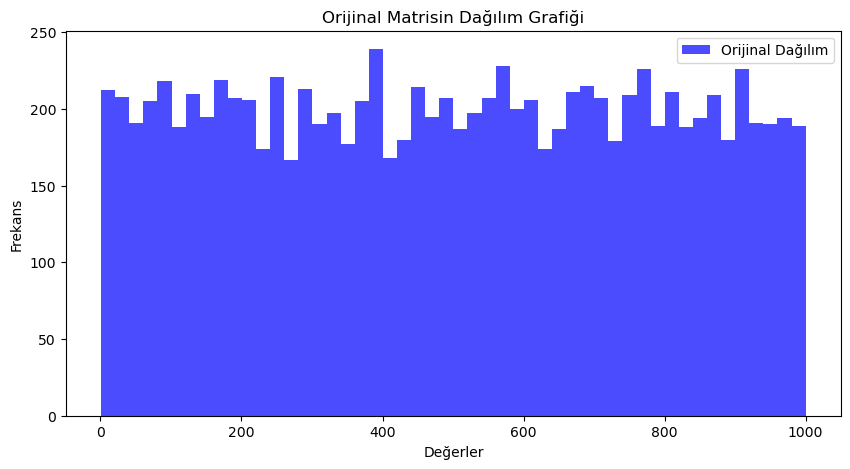

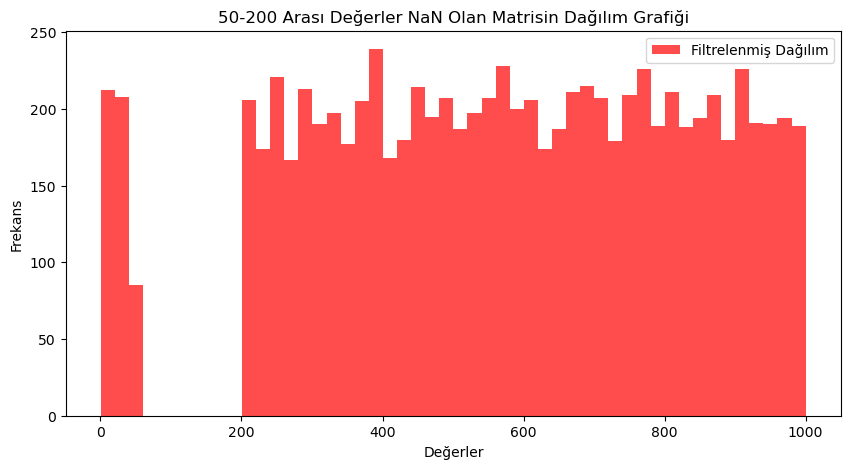

In [13]:
import numpy as np
import matplotlib.pyplot as plt

matrix = np.random.randint(1, 1001, (100, 100))

plt.figure(figsize=(10, 5))
plt.hist(matrix.flatten(), bins=50, color='blue', alpha=0.7, label="Orijinal Dağılım")
plt.xlabel("Değerler")
plt.ylabel("Frekans")
plt.title("Orijinal Matrisin Dağılım Grafiği")
plt.legend()
plt.show()


matrix_filtered = matrix.astype(float)
matrix_filtered[(matrix_filtered >= 50) & (matrix_filtered <= 200)] = np.nan

plt.figure(figsize=(10, 5))
plt.hist(matrix_filtered[~np.isnan(matrix_filtered)], bins=50, color='red', alpha=0.7, label="Filtrelenmiş Dağılım")
plt.xlabel("Değerler")
plt.ylabel("Frekans")
plt.title("50-200 Arası Değerler NaN Olan Matrisin Dağılım Grafiği")
plt.legend()
plt.show()

Küp boyutları (spektral, y, x): (13100, 242, 122)
Veri birimi: K
Spektral eksen birimi: m / s


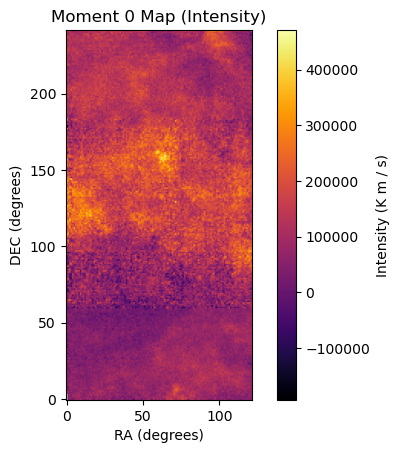

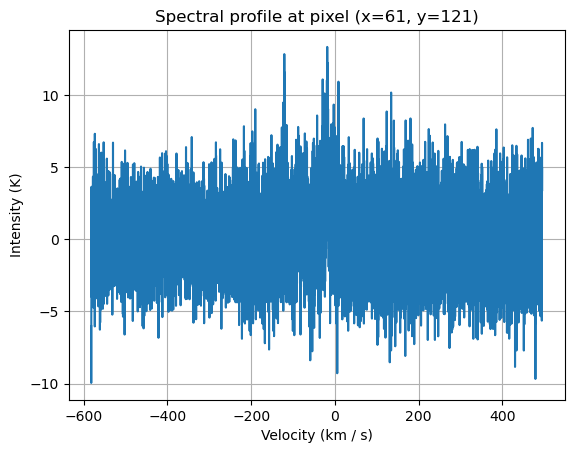

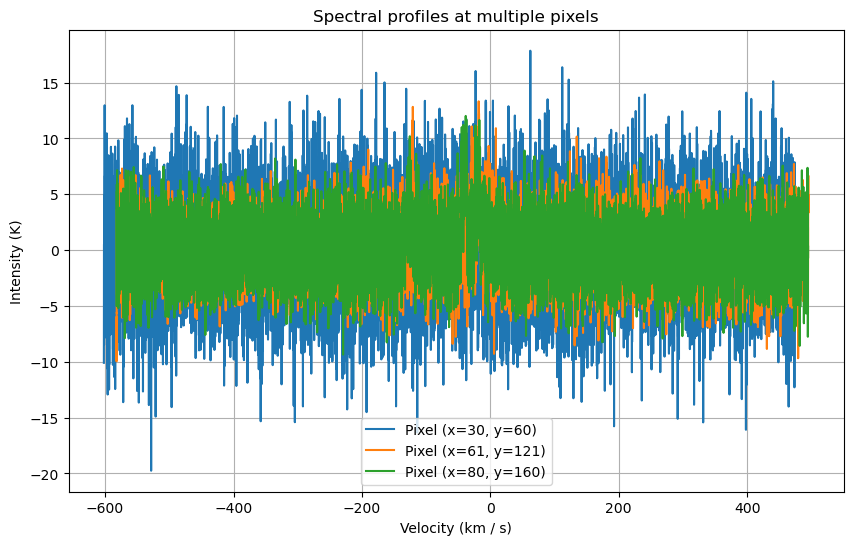

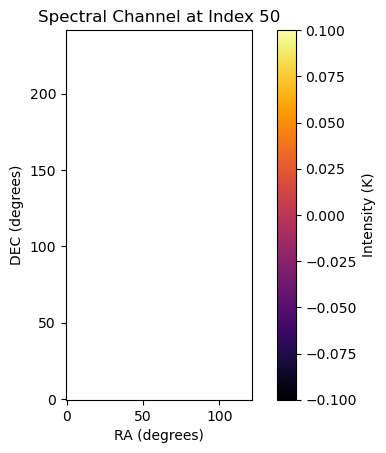

In [14]:
# Gerekli kütüphaneleri içeri aktar
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube

# FITS dosyasını oku
cube = SpectralCube.read(r"C:\Users\User\Downloads\G345.5-1+1-12CO_clean.fits")

# Küpün boyutları hakkında bilgi al
print(f"Küp boyutları (spektral, y, x): {cube.shape}")
print(f"Veri birimi: {cube.unit}")
print(f"Spektral eksen birimi: {cube.spectral_axis.unit}")
# Spektral eksende entegrasyon yaparak moment 0 haritasını al
moment0 = cube.moment(order=0)

# Görselleştir
plt.imshow(moment0.value, origin='lower', cmap='inferno')
plt.colorbar(label=f"Intensity ({moment0.unit})")
plt.title("Moment 0 Map (Intensity)")
plt.xlabel("RA (degrees)")
plt.ylabel("DEC (degrees)")
plt.show()
# Orta noktayı seç (y, x)
y = cube.shape[1] // 2
x = cube.shape[2] // 2

# Bu pikselin spektral profilini al
spectrum = cube[:, y, x]

# Spektral eksen birimi (hız cinsinden, örneğin km/s)
spectral_axis = cube.spectral_axis.to('km/s')

# Spektrumu çiz
plt.plot(spectral_axis, spectrum.value)
plt.xlabel(f"Velocity ({spectral_axis.unit})")
plt.ylabel(f"Intensity ({spectrum.unit})")
plt.title(f"Spectral profile at pixel (x={x}, y={y})")
plt.grid(True)
plt.show()
# Örnek olarak birkaç farklı piksel seçelim (burada y1, x1 ve y2, x2'yi istediğin gibi değiştirebilirsin)
pixels = [(cube.shape[1]//4, cube.shape[2]//4), (cube.shape[1]//2, cube.shape[2]//2), (cube.shape[1]//3*2, cube.shape[2]//3*2)]

# Her piksel için spektral profil alıp çiz
plt.figure(figsize=(10, 6))
for (y, x) in pixels:
    spectrum = cube[:, y, x]
    plt.plot(spectral_axis, spectrum.value, label=f"Pixel (x={x}, y={y})")

plt.xlabel(f"Velocity ({spectral_axis.unit})")
plt.ylabel(f"Intensity ({spectrum.unit})")
plt.title("Spectral profiles at multiple pixels")
plt.legend()
plt.grid(True)
plt.show()
import matplotlib.pyplot as plt
from spectral_cube import SpectralCube

# FITS dosyasını oku
cube = SpectralCube.read(r"C:\Users\User\Downloads\G345.5-1+1-12CO_clean.fits")

# Belirli bir spektral kanal (örneğin, 50. kanal) al ve görselleştir
channel = cube[50, :, :]  # 50. spektral kanal

# Görselleştir
plt.imshow(channel.value, origin='lower', cmap='inferno')
plt.colorbar(label=f"Intensity ({channel.unit})")
plt.title(f"Spectral Channel at Index 50")
plt.xlabel("RA (degrees)")
plt.ylabel("DEC (degrees)")
plt.show()

import plotly.graph_objects as go
import numpy as np

# Küpün boyutlarını al
n_s, n_y, n_x = cube.shape

# Her spektral kanal için veri al (spektral eksende tüm kanallar)
data = cube.filled_data[:].value  # (spectral, y, x)
  # (spektral, y, x)


In [7]:
import warnings
import numpy as np
from astropy.io import fits
from astropy.utils.exceptions import AstropyUserWarning

warnings.filterwarnings('ignore', category=AstropyUserWarning)
warnings.filterwarnings('ignore', category=UserWarning)

fits_path = r"C:\\Users\\User\\Downloads\\G345.5-1+1-12CO_clean.fits"

print("FITS dosyası memory-map ile açılıyor...")
hdul = fits.open(fits_path, memmap=True)
data = hdul[0].data  # (z, y, x)

print("Kanal ortalamaları hesaplanıyor (memory-map ile)...")
mean_per_channel = []
for i in range(data.shape[0]):
    chan_data = data[i, :, :]
    if np.isnan(chan_data).all():
        mean_per_channel.append(np.nan)  # Tamamen boş kanal
    else:
        mean_per_channel.append(np.nanmean(chan_data))
mean_per_channel = np.array(mean_per_channel)

# NaN olmayan kanalların ortalamalarına bak
valid_means = np.where(np.isnan(mean_per_channel), -np.inf, mean_per_channel)
# Belirli kanal aralığında sigma hesapla (1000–1110)
start_channel = 1000
end_channel = 1110

if end_channel > data.shape[0]:
    raise ValueError(f"Veride sadece {data.shape[0]} kanal var, ama {end_channel} istenmiş.")

print(f"Kanal {start_channel}–{end_channel} arası için sigma hesaplanıyor...")
sigma_value = np.nanmean(data[start_channel:end_channel, :, :])
print(f"Sigma (1000–1110 arası): {sigma_value}")

# 3σ maskesi uygula
print("3σ maskesi uygulanıyor (memory-map ile)...")
mask = data > (3 * sigma_value)
masked_data = np.where(mask, data, np.nan)

# Yeni FITS kaydet (masaüstüne)
save_path = r"C:\\Users\\User\\Downloads\\G345.5-1+1-12CO_clean1.fits"
print(f"Yeni FITS kaydediliyor: {save_path}")
hdu = fits.PrimaryHDU(masked_data, header=hdul[0].header)
hdu.writeto(save_path, overwrite=True)

print("✅ 3sigma-masked.fits masaüstüne kaydedildi.")

FITS dosyası memory-map ile açılıyor...
Kanal ortalamaları hesaplanıyor (memory-map ile)...
Kanal 1000–1110 arası için sigma hesaplanıyor...
Sigma (1000–1110 arası): 0.029591461643576622
3σ maskesi uygulanıyor (memory-map ile)...
Yeni FITS kaydediliyor: C:\\Users\\User\\Downloads\\G345.5-1+1-12CO_clean1.fits
✅ 3sigma-masked.fits masaüstüne kaydedildi.
